# Generate plot for sc QC results

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
import string
import re

sns.set_theme(style="whitegrid")

In [2]:
# Load all qc_labeled_profiles files and add Metadata_layout from grandparent folder
data_folder = Path("../3.preprocessing_features/data")
qc_files = list(data_folder.rglob("*qc_labeled.parquet"))

df_list = []
for file in qc_files:
    df = pd.read_parquet(file)
    # grandparent folder name as Metadata_layout
    df["Metadata_layout"] = file.parent.parent.name
    df_list.append(df)

qc_data = pd.concat(df_list, ignore_index=True)

# Create Metadata_plate_alias per layout (e.g., 1A, 1B, 1C, etc.)
plate_alias_map = {}
for layout, plates in qc_data.groupby("Metadata_layout")["Image_Metadata_Plate"]:
    unique_plates = sorted(plates.unique())  # keep order consistent

    # Extract the numeric part of the layout name
    layout_num = re.search(r"\d+", layout).group()

    letters = list(string.ascii_uppercase)
    aliases = [f"{layout_num}{letters[i]}" for i in range(len(unique_plates))]

    plate_alias_map.update(dict(zip(unique_plates, aliases)))

qc_data["Metadata_plate_alias"] = qc_data["Image_Metadata_Plate"].map(plate_alias_map)

qc_data.head()

,Metadata_Nuclei_Location_Center_X,Metadata_Nuclei_Location_Center_Y,Metadata_Cells_Location_Center_X,Metadata_Cells_Location_Center_Y,Metadata_Image_Count_Cells,Metadata_ImageNumber,Image_Metadata_Plate,Image_Metadata_Site,Image_Metadata_Well,Metadata_Cells_Number_Object_Number,...,Nuclei_Texture_Variance_PM_3_00_256,Nuclei_Texture_Variance_PM_3_01_256,Nuclei_Texture_Variance_PM_3_02_256,Nuclei_Texture_Variance_PM_3_03_256,Metadata_cqc_failed_oversegmented_nuclei,Metadata_cqc_failed_small_cells,Metadata_cqc_failed_low_intensity,Metadata_cqc_failed_blurry_cells,Metadata_layout,Metadata_plate_alias
0,287.084866,66.361386,280.130645,70.825769,11,5,CARD-CelIns-CX7_251230180001,f04,B02,1,...,0.710252,0.659385,0.706624,0.677847,False,False,False,True,platemap_7,7B
1,96.626846,69.034040,96.626846,69.034040,15,8,CARD-CelIns-CX7_251230180001,f07,B02,1,...,1.063830,0.929685,1.008718,1.138980,False,True,False,False,platemap_7,7B
2,877.100763,329.054962,877.015017,317.920096,8,42,CARD-CelIns-CX7_251230180001,f16,B03,1,...,2.385855,2.097175,2.364700,2.492849,False,False,False,False,platemap_7,7B
3,381.039441,128.476582,380.183155,162.394574,7,63,CARD-CelIns-CX7_251230180001,f12,B04,1,...,6.451773,6.658664,6.422328,5.903021,False,False,False,True,platemap_7,7B
4,664.150000,108.468182,691.622366,131.028309,5,67,CARD-CelIns-CX7_251230180001,f17,B04,1,...,3.934808,3.999207,4.311827,3.788093,False,False,False,False,platemap_7,7B


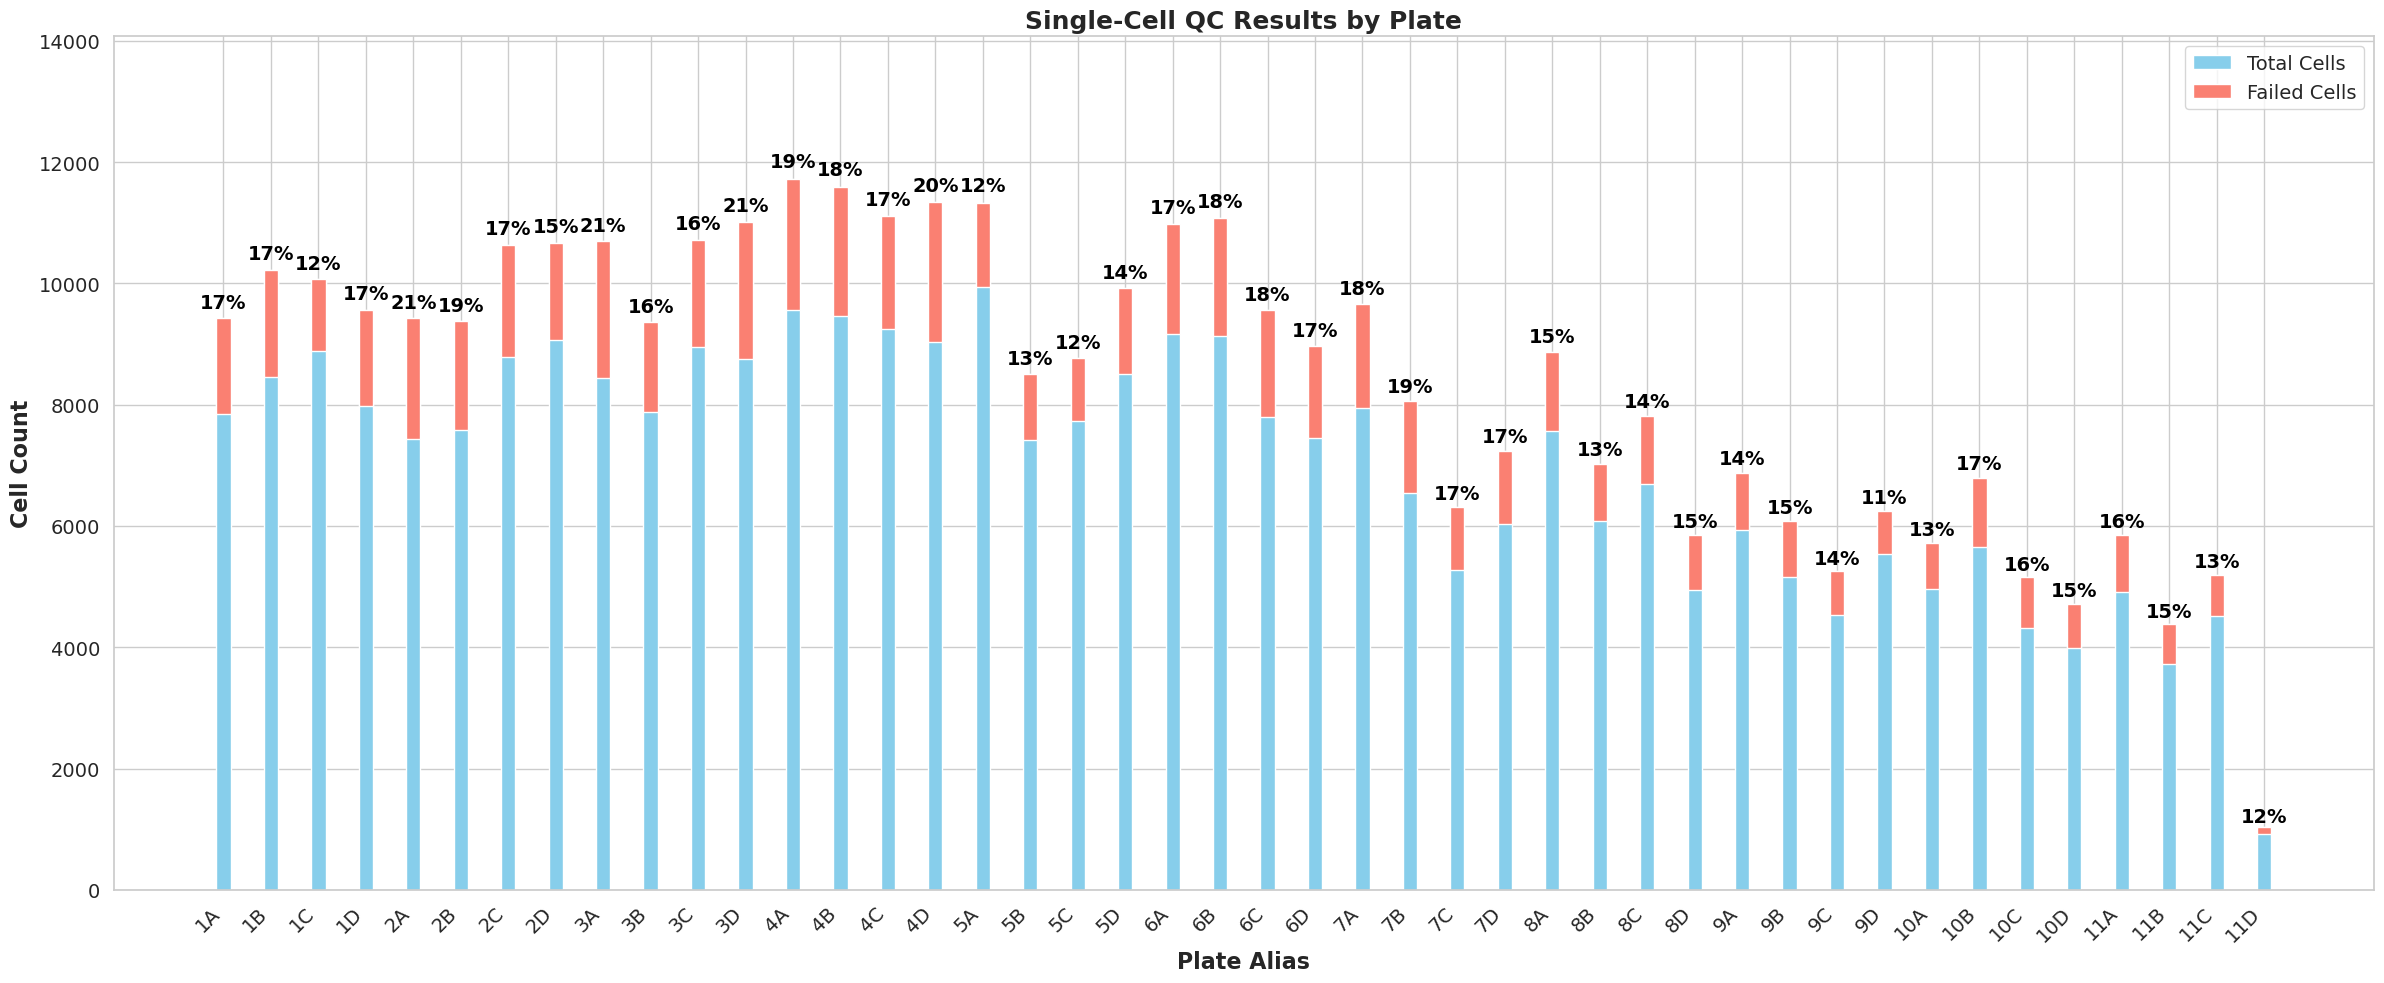

In [3]:
# Identify cells that failed QC if 'cqc' is in the column name
qc_data["failed_qc"] = qc_data.filter(like="cqc").any(axis=1)

# Group data by plate alias
plate_summary = (
    qc_data.groupby("Metadata_plate_alias")
    .agg(total_cells=("failed_qc", "size"), failed_cells=("failed_qc", "sum"))
    .reset_index()
)

# Calculate percentage failed
plate_summary["percent_failed"] = (
    plate_summary["failed_cells"] / plate_summary["total_cells"]
) * 100

# Ensure proper order of aliases (sorted by layout number then letter)
plate_summary = plate_summary.sort_values(
    by=["Metadata_plate_alias"],
    key=lambda x: x.str.extract(r"(\d+)([A-Z])").apply(
        lambda y: (int(y[0]), ord(y[1])), axis=1
    ),
).reset_index(drop=True)

# -------------------------------
# Plotting
# -------------------------------
plt.figure(figsize=(max(24, len(plate_summary) * 0.5), 10))  # bigger figure for slides
bar_width = 0.3  # skinnier bars
x = range(len(plate_summary))

# Total cells and failed cells bars
plt.bar(
    x,
    plate_summary["total_cells"],
    width=bar_width,
    label="Total Cells",
    color="skyblue",
)
plt.bar(
    x,
    plate_summary["failed_cells"],
    width=bar_width,
    label="Failed Cells",
    color="salmon",
    bottom=plate_summary["total_cells"] - plate_summary["failed_cells"],
)

# Add percentage failed above the bars with dynamic offset
for i, row in plate_summary.iterrows():
    pct_text = f"{row['percent_failed']:.0f}%"
    # place a little above the top of the total bar, proportional to bar height
    y_pos = row["total_cells"] + row["total_cells"] * 0.01 + 5
    plt.text(
        i,
        y_pos,
        pct_text,
        ha="center",
        va="bottom",
        fontsize=14,
        fontweight="bold",
        color="black",
    )

# Customize plot with aliases on x-axis
plt.xticks(
    x, plate_summary["Metadata_plate_alias"], rotation=45, ha="right", fontsize=14
)
plt.yticks(fontsize=14)
plt.ylim(0, plate_summary["total_cells"].max() * 1.2)  # add some space for text
plt.xlabel("Plate Alias", fontsize=16, fontweight="bold")
plt.ylabel("Cell Count", fontsize=16, fontweight="bold")
plt.title("Single-Cell QC Results by Plate", fontsize=18, fontweight="bold")
plt.legend(fontsize=14)
plt.tight_layout()

# Save the figure
plt.savefig("./figures/QC_results_by_plate_slide.png", dpi=300)
plt.show()